In [1]:
import joblib

# Load everything back into memory
preprocessor = joblib.load('../data/processed/preprocessor.joblib')
X_train, y_train = joblib.load('../data/processed/train_data_resampled.joblib')
X_test, y_test = joblib.load('../data/processed/test_data_transformed.joblib')

print("Data loaded. You are ready to build your Baseline Logistic Regression model.")

Data loaded. You are ready to build your Baseline Logistic Regression model.


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Initialize the model
# We use max_iter=1000 to ensure the solver converges on the scaled data
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Fit the model on the RESAMPLED training data
log_reg.fit(X_train, y_train)

# 3. Make predictions on the TRANSFORMED test data
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1] # Probability estimates for AUC-PR

In [3]:
print("--- Baseline Logistic Regression Report ---")
print(classification_report(y_test, y_pred))

--- Baseline Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     27393
           1       0.58      0.65      0.62      2830

    accuracy                           0.92     30223
   macro avg       0.77      0.80      0.79     30223
weighted avg       0.93      0.92      0.93     30223



<Figure size 800x600 with 0 Axes>

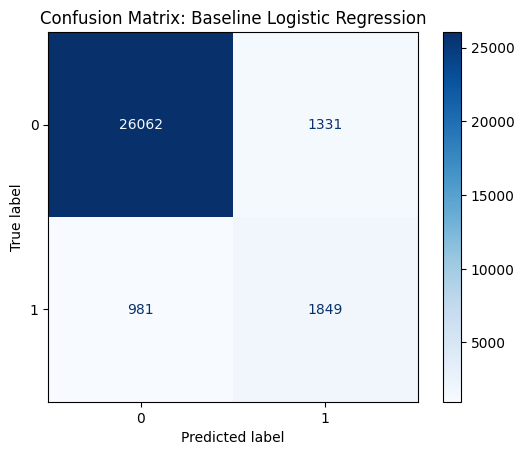

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix: Baseline Logistic Regression")
plt.show()

Average Precision (AUC-PR): 0.6594


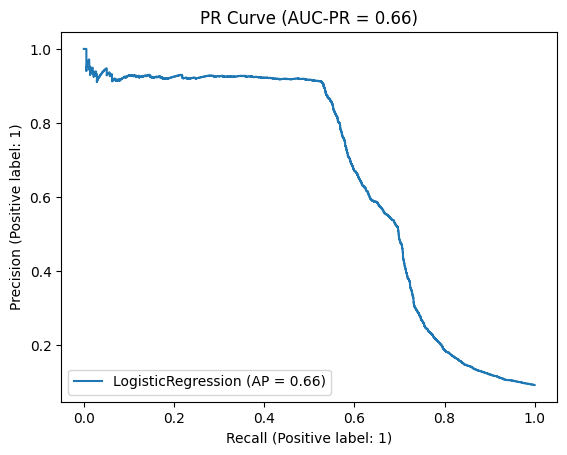

In [6]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

aucppr = average_precision_score(y_test, y_prob)
print(f"Average Precision (AUC-PR): {aucppr:.4f}")

PrecisionRecallDisplay.from_estimator(log_reg, X_test, y_test)
plt.title(f"PR Curve (AUC-PR = {aucppr:.2f})")
plt.show()

In [7]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# 1. Initialize XGBoost
# Use scale_pos_weight to handle the ~9% imbalance further
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=10)

# 2. Hyperparameter Tuning (Required for Task 2)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_search = RandomizedSearchCV(xgb, param_grid, cv=3, scoring='f1', n_iter=5, random_state=42)
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
print(f"Best Params: {xgb_search.best_params_}")

c:\Users\Her\Desktop\Week-5&6\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:07:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Her\Desktop\Week-5&6\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:07:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Her\Desktop\Week-5&6\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:07:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Her\Desktop\Week-5&6\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:07:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_labe

Best Params: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}


In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=skf, scoring='f1')

print(f"Mean F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

c:\Users\Her\Desktop\Week-5&6\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:09:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Her\Desktop\Week-5&6\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:10:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Her\Desktop\Week-5&6\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:10:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Her\Desktop\Week-5&6\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:10:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_labe

Mean F1-Score: 0.8535 (+/- 0.0046)


In [9]:
import joblib
joblib.dump(best_xgb, '../models/best_fraud_model.joblib')
print("Best model saved to ../models/")

Best model saved to ../models/
